# Evaluation and Model Comparison

Merangkum hasil evaluasi semua model dan membuat visualisasi.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Deteksi folder output secara dinamis (Colab vs Lokal)
output_dir = 'outputs' if os.path.exists('data') or os.path.exists('Data') else '../outputs'
os.makedirs(f'{output_dir}/figures', exist_ok=True)

## 1. Load Semua Hasil

In [2]:
try:
    baseline_df = pd.read_csv(f'{output_dir}/baseline_results.csv')
except: baseline_df = pd.DataFrame()

try:
    dl_df = pd.read_csv(f'{output_dir}/dl_results.csv')
except: dl_df = pd.DataFrame()

try:
    indobert_df = pd.read_csv(f'{output_dir}/indobert_results.csv')
except: indobert_df = pd.DataFrame()

all_results = pd.concat([baseline_df, dl_df, indobert_df], ignore_index=True)
all_results

,Model,Accuracy,F1-Score
0,SVM,0.900992,0.900270
1,Logistic Regression,0.892873,0.891731
2,Naive Bayes,0.841678,0.829737


## 2. Visualisasi Perbandingan F1-Score

C:\Users\USER\AppData\Local\Temp\ipykernel_7104\3635095787.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=all_results.sort_values('F1-Score', ascending=False), x='Model', y='F1-Score', palette='viridis')


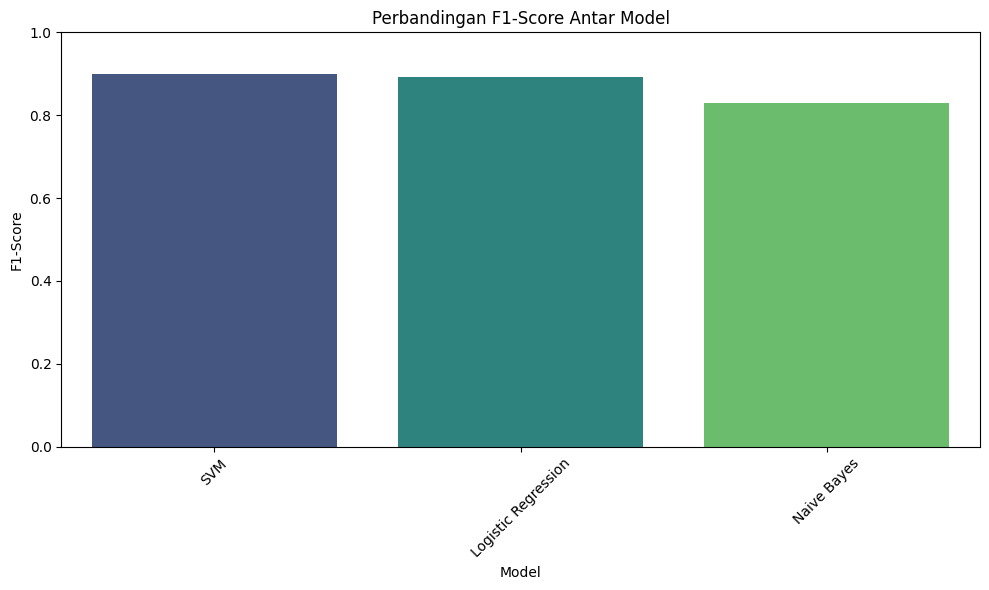

In [3]:
plt.figure(figsize=(10, 6))
sns.barplot(data=all_results.sort_values('F1-Score', ascending=False), x='Model', y='F1-Score', palette='viridis')
plt.title('Perbandingan F1-Score Antar Model')
plt.ylim(0, 1.0)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f'{output_dir}/figures/f1_score_comparison.png')
plt.show()

## 3. Visualisasi Confusion Matrix Model Terbaik (IndoBERT)
*Catatan: Pastikan sudah load model IndoBERT dan prediksikan test set sebelum membuat plot ini.*

In [4]:
import joblib
import numpy as np
from sklearn.metrics import confusion_matrix

# Contoh jika ingin memplot CM secara mandiri di sini (opsional)
# Jika sudah dihitung di notebook sebelumnya, load array CM-nya.

print("Rangkuman Eksekusi Selesai!")

Rangkuman Eksekusi Selesai!


## 4. Visualisasi Kurva Pelatihan & Confusion Matrix untuk Draf Jurnal (Gambar 2 - 10)


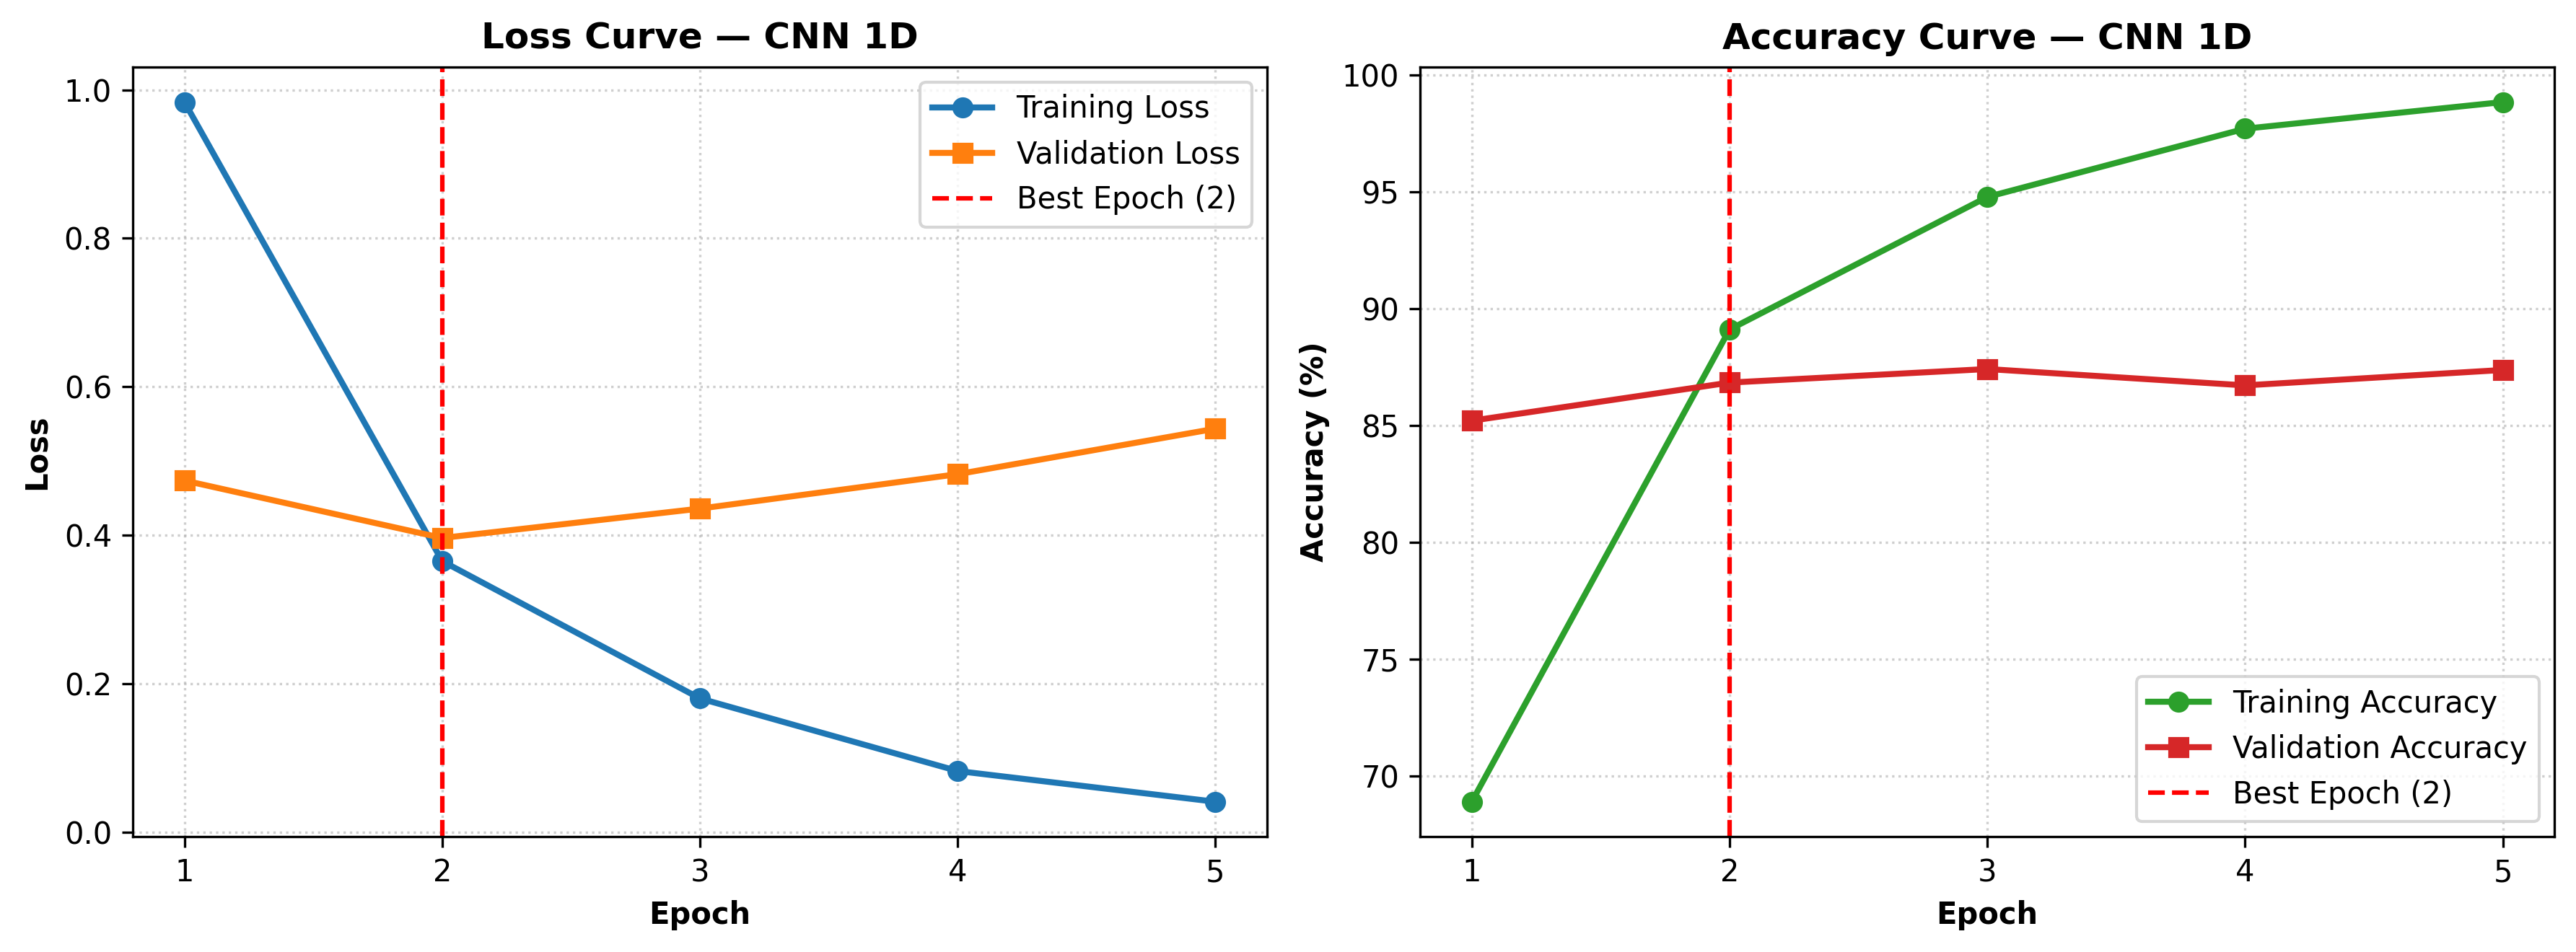

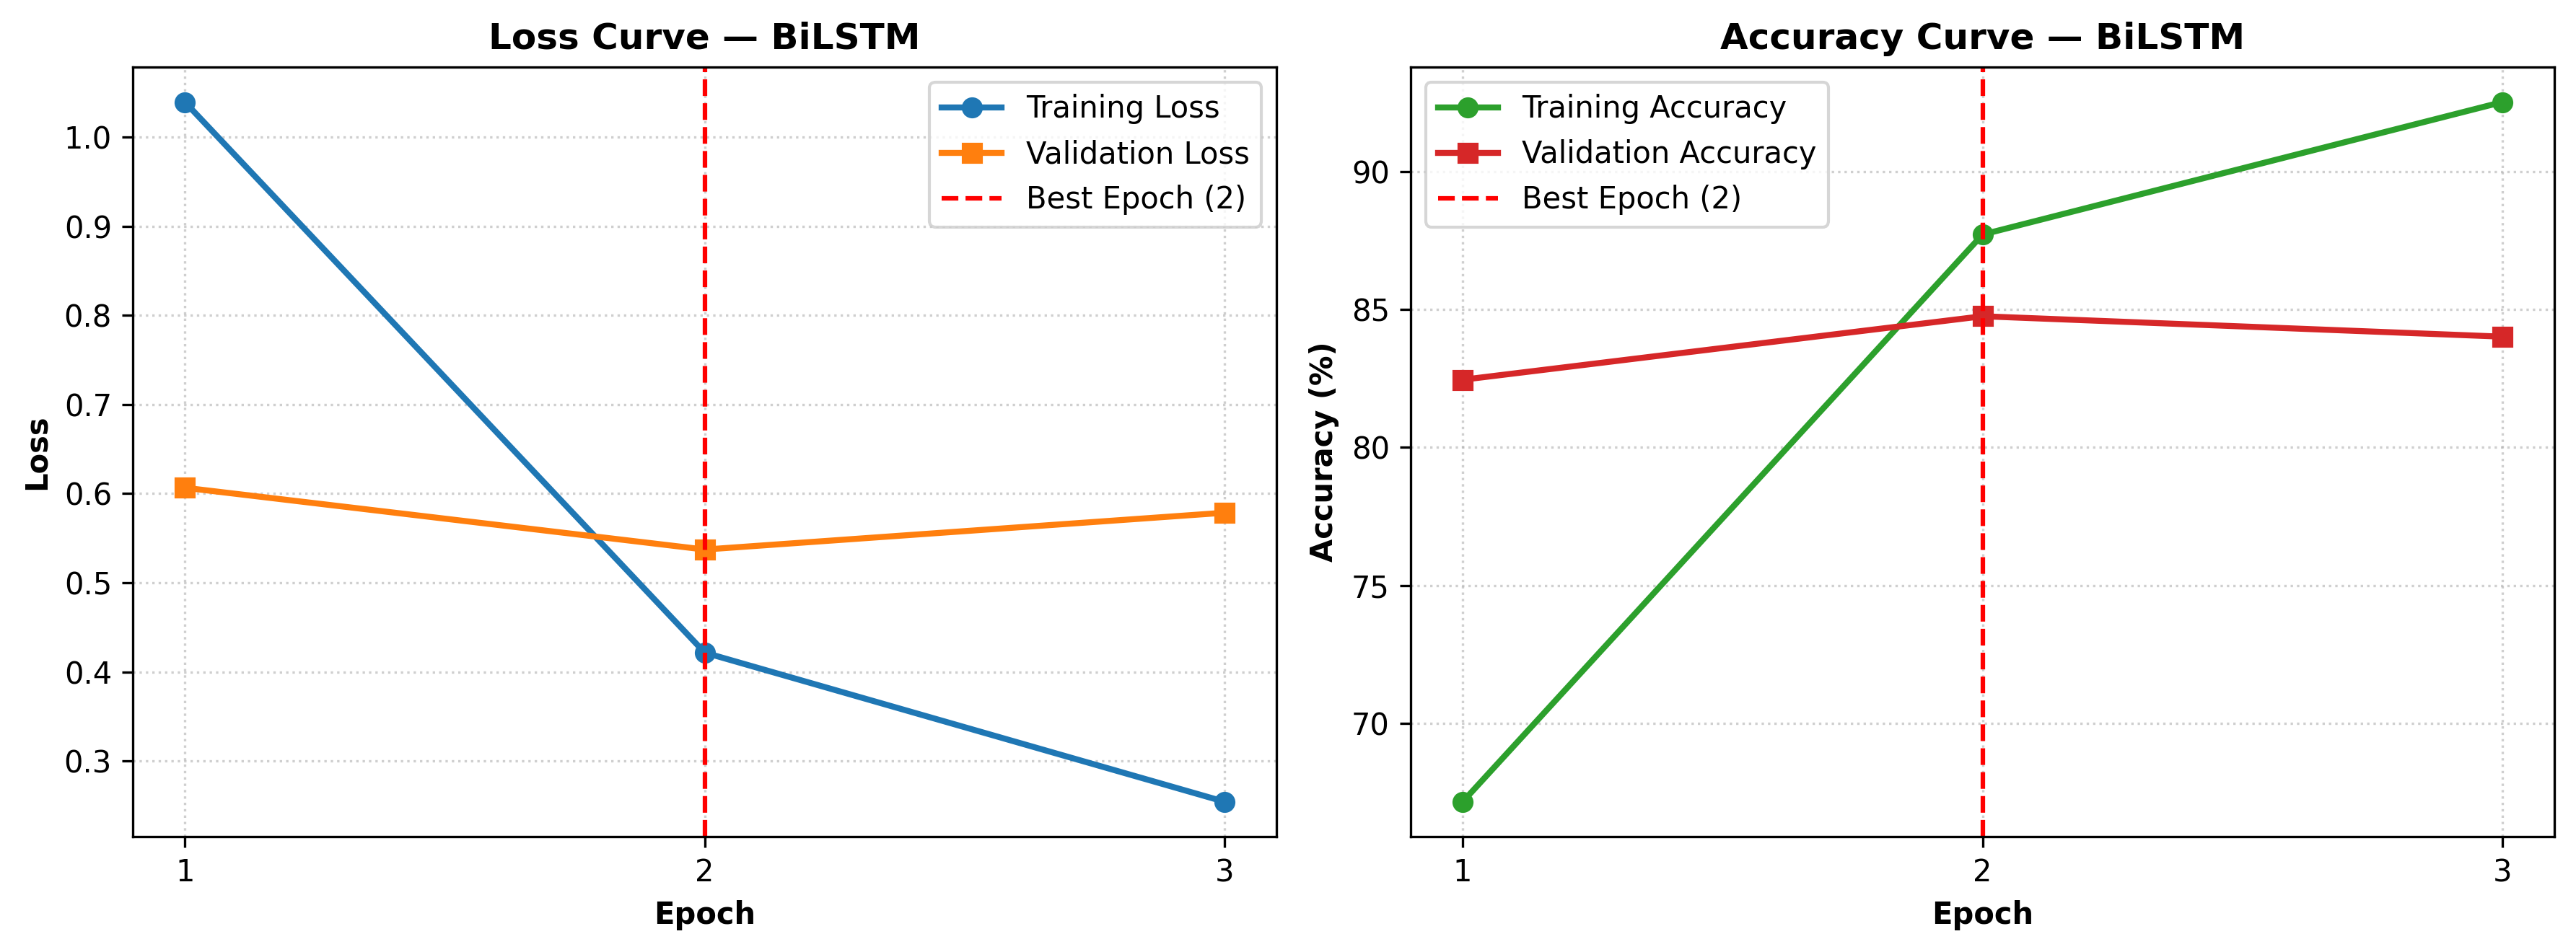

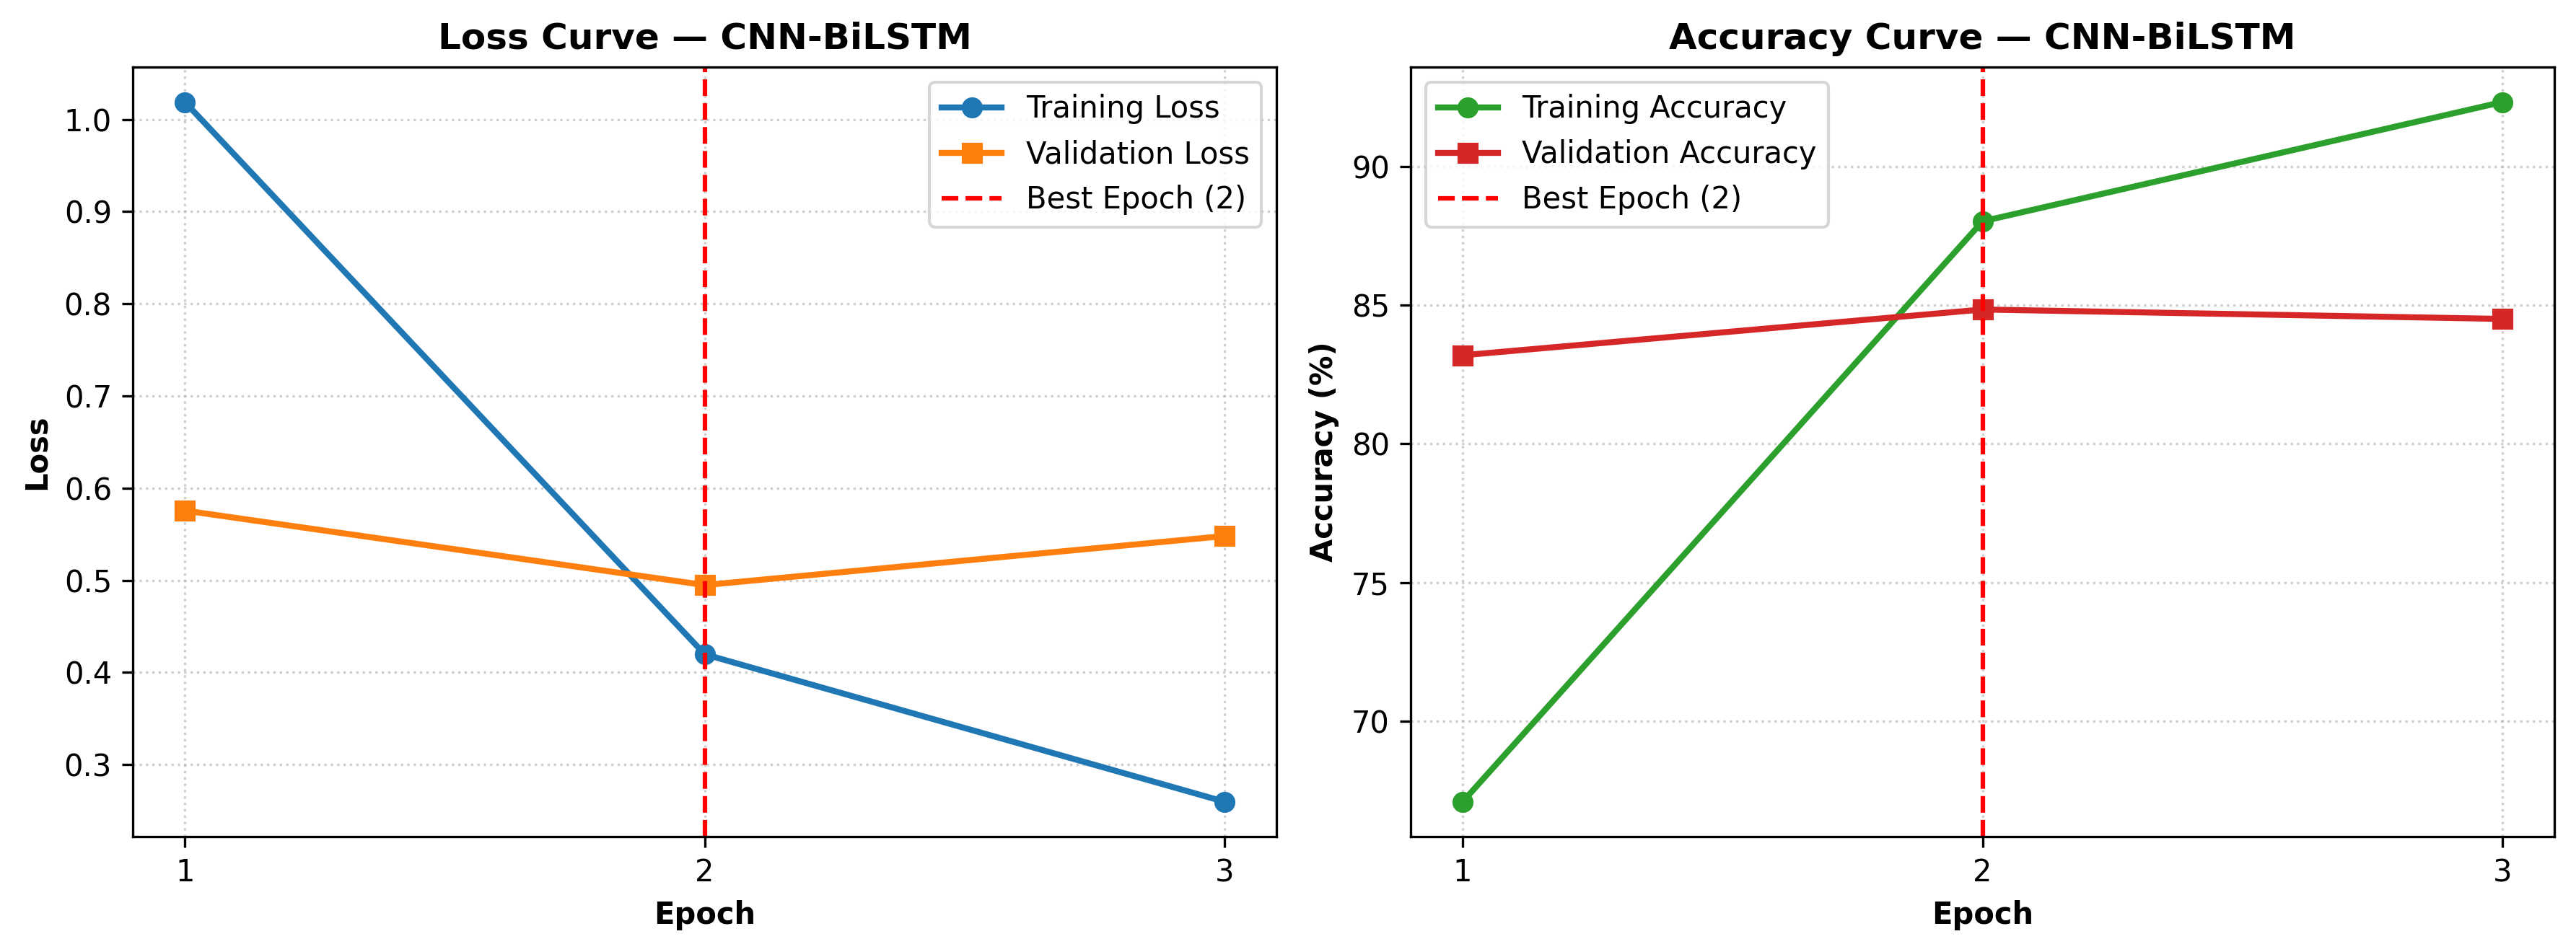

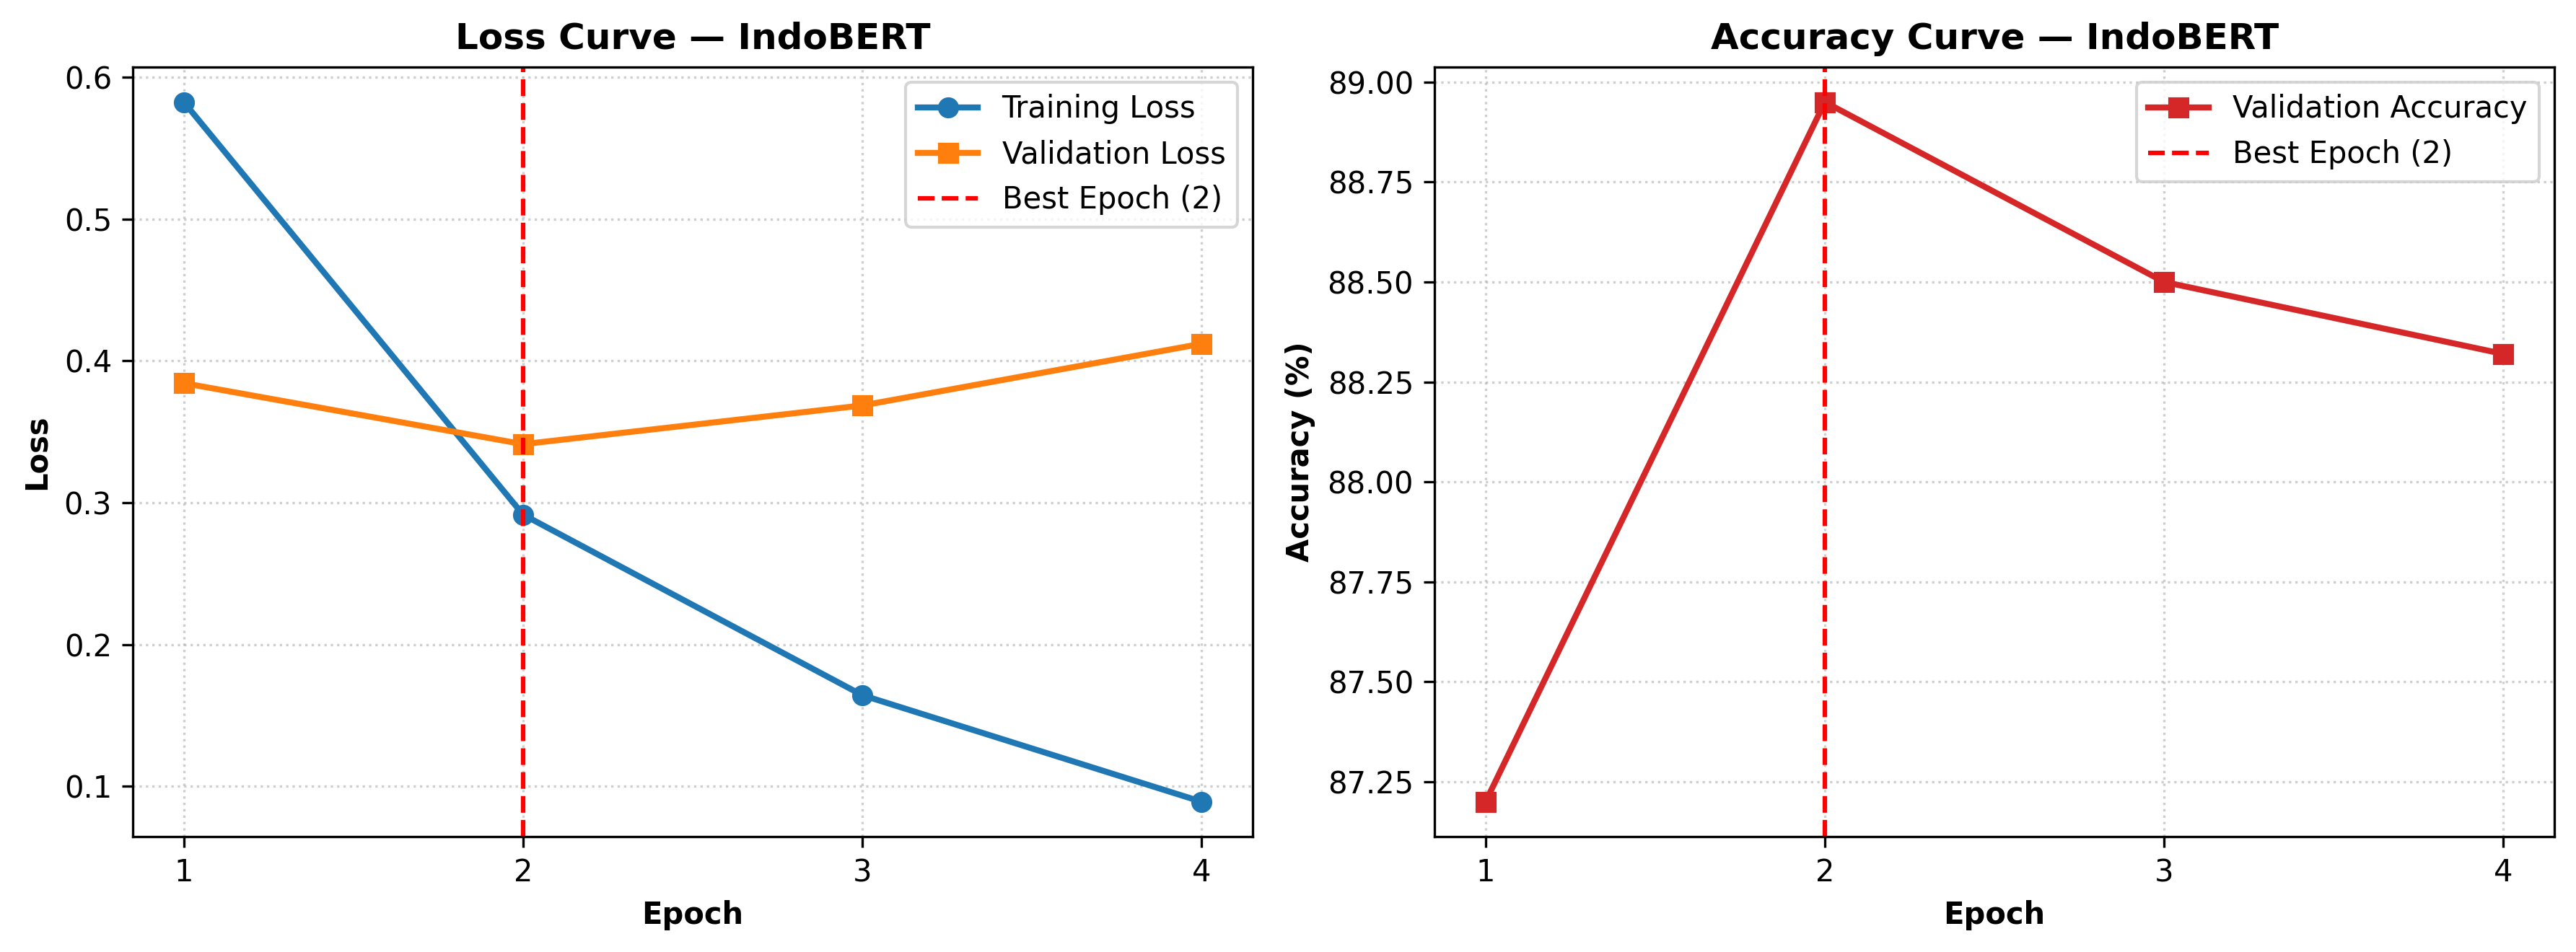

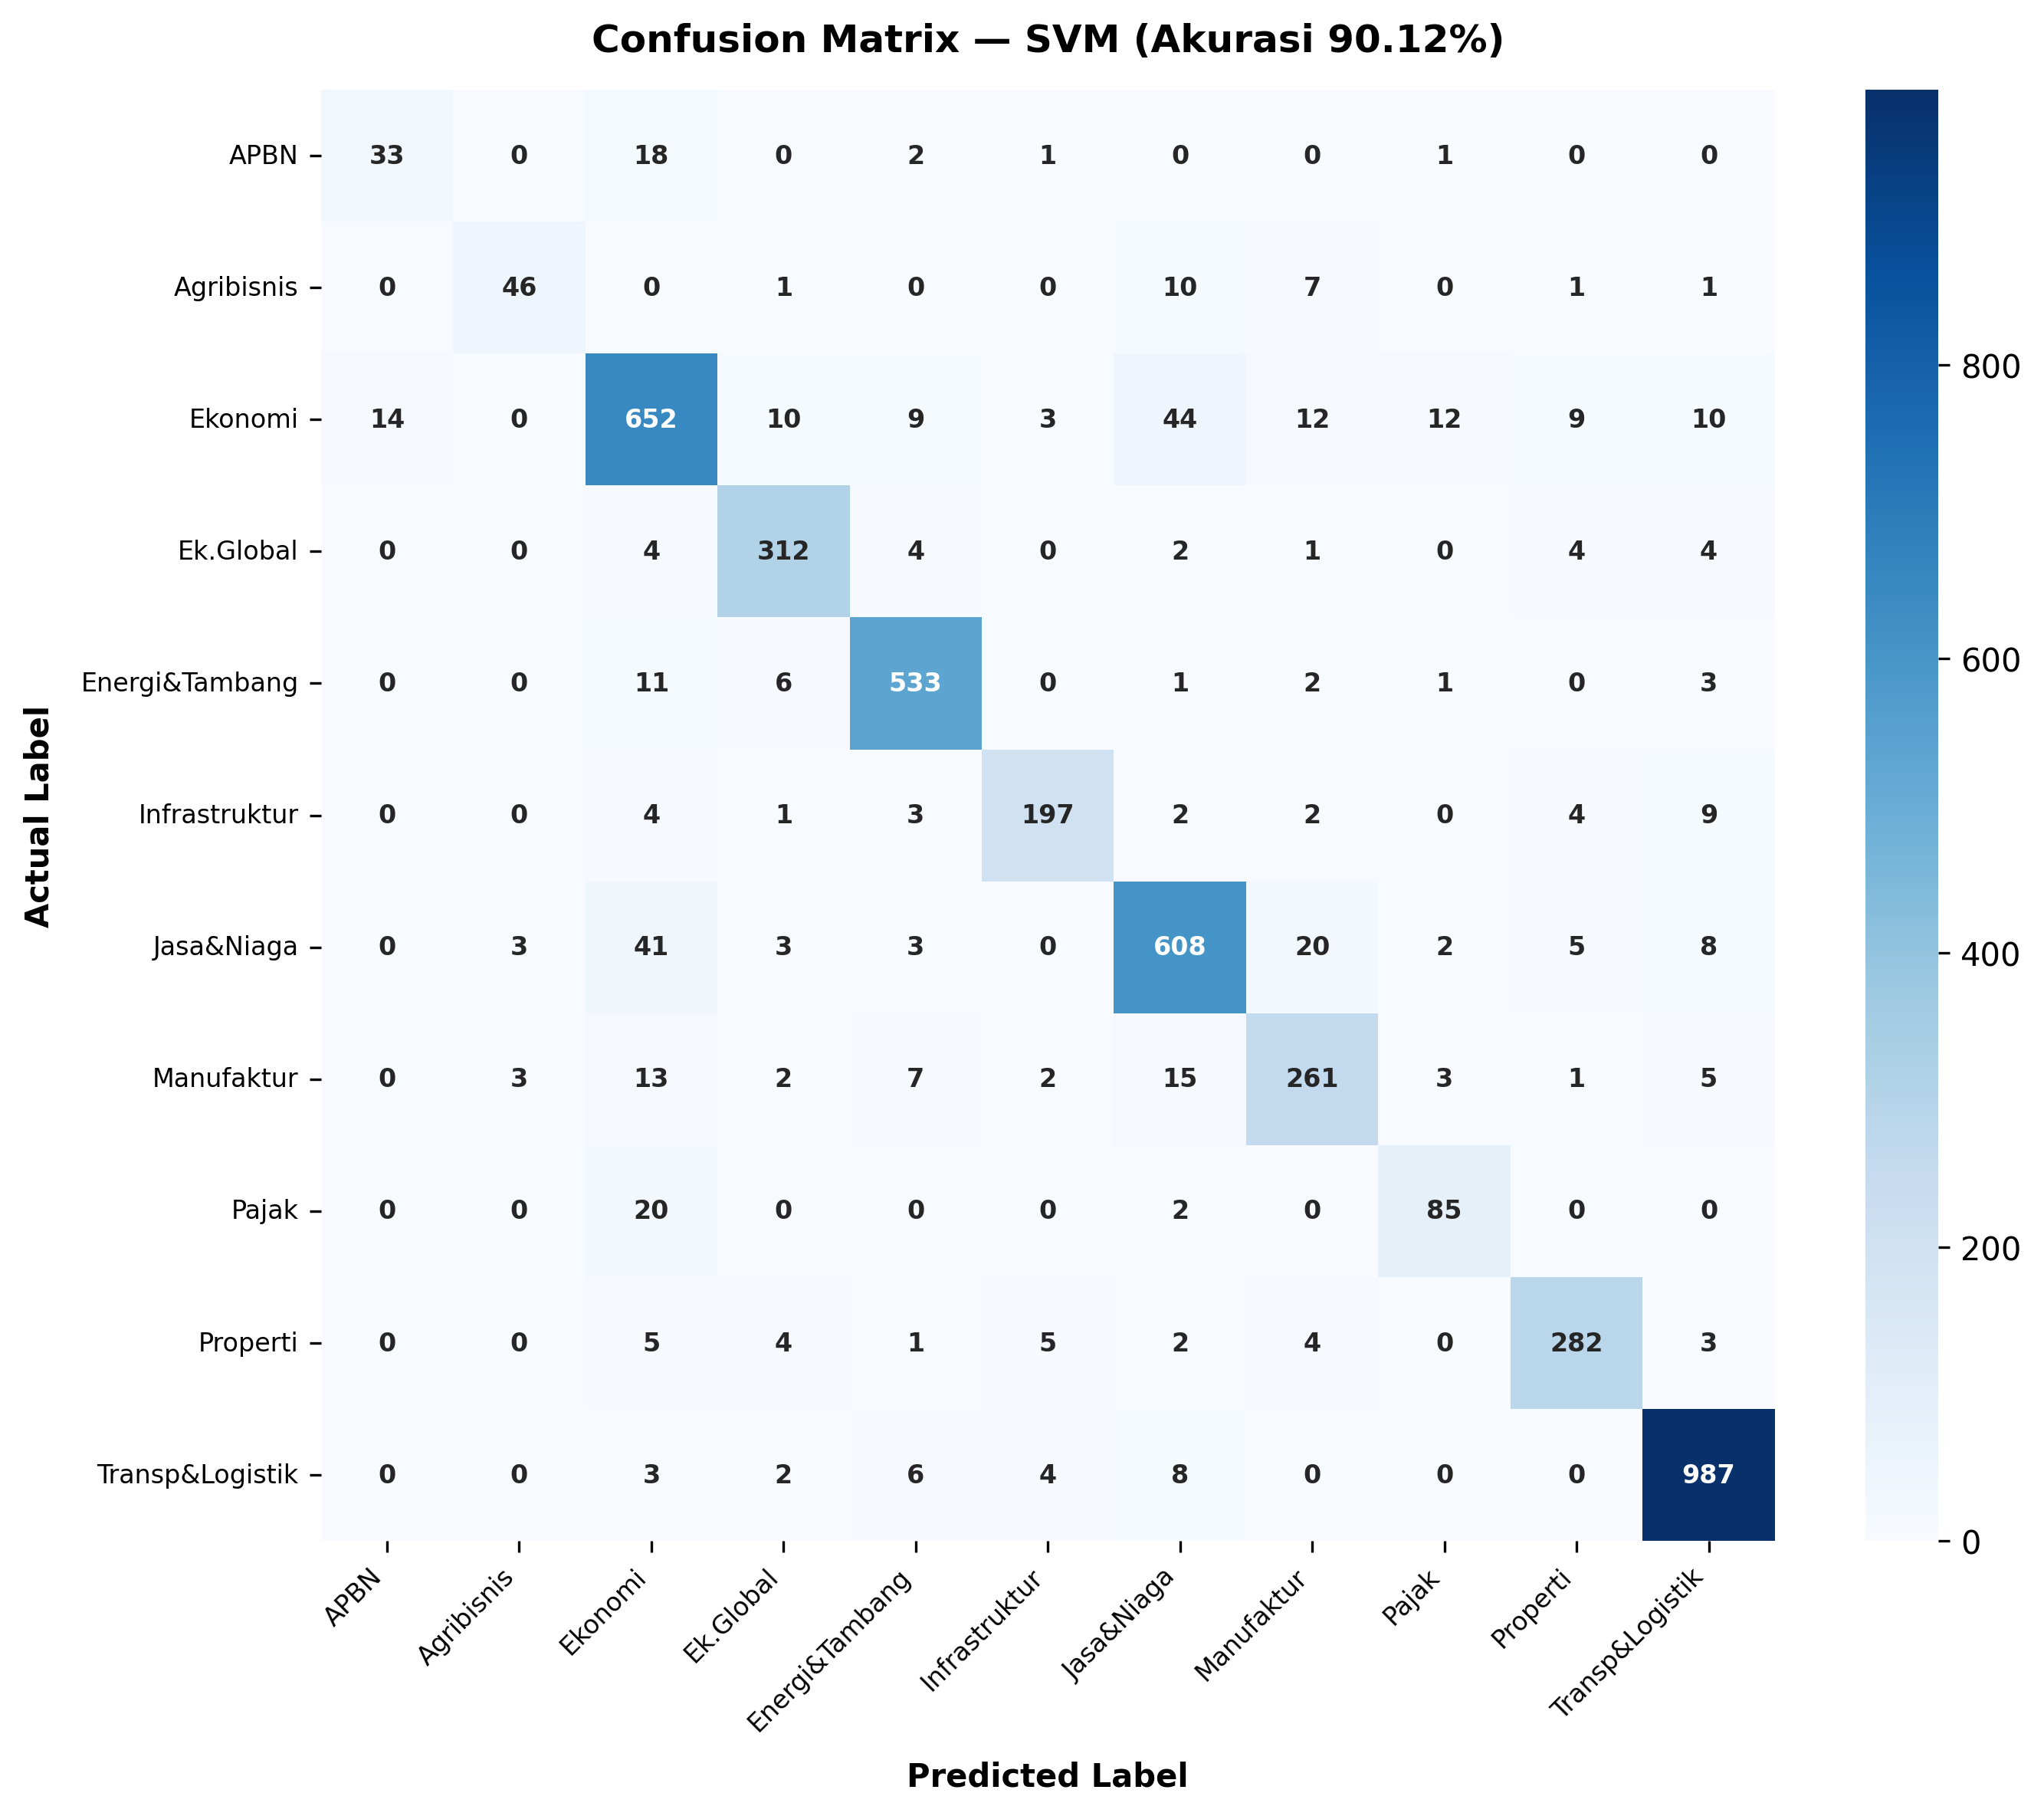

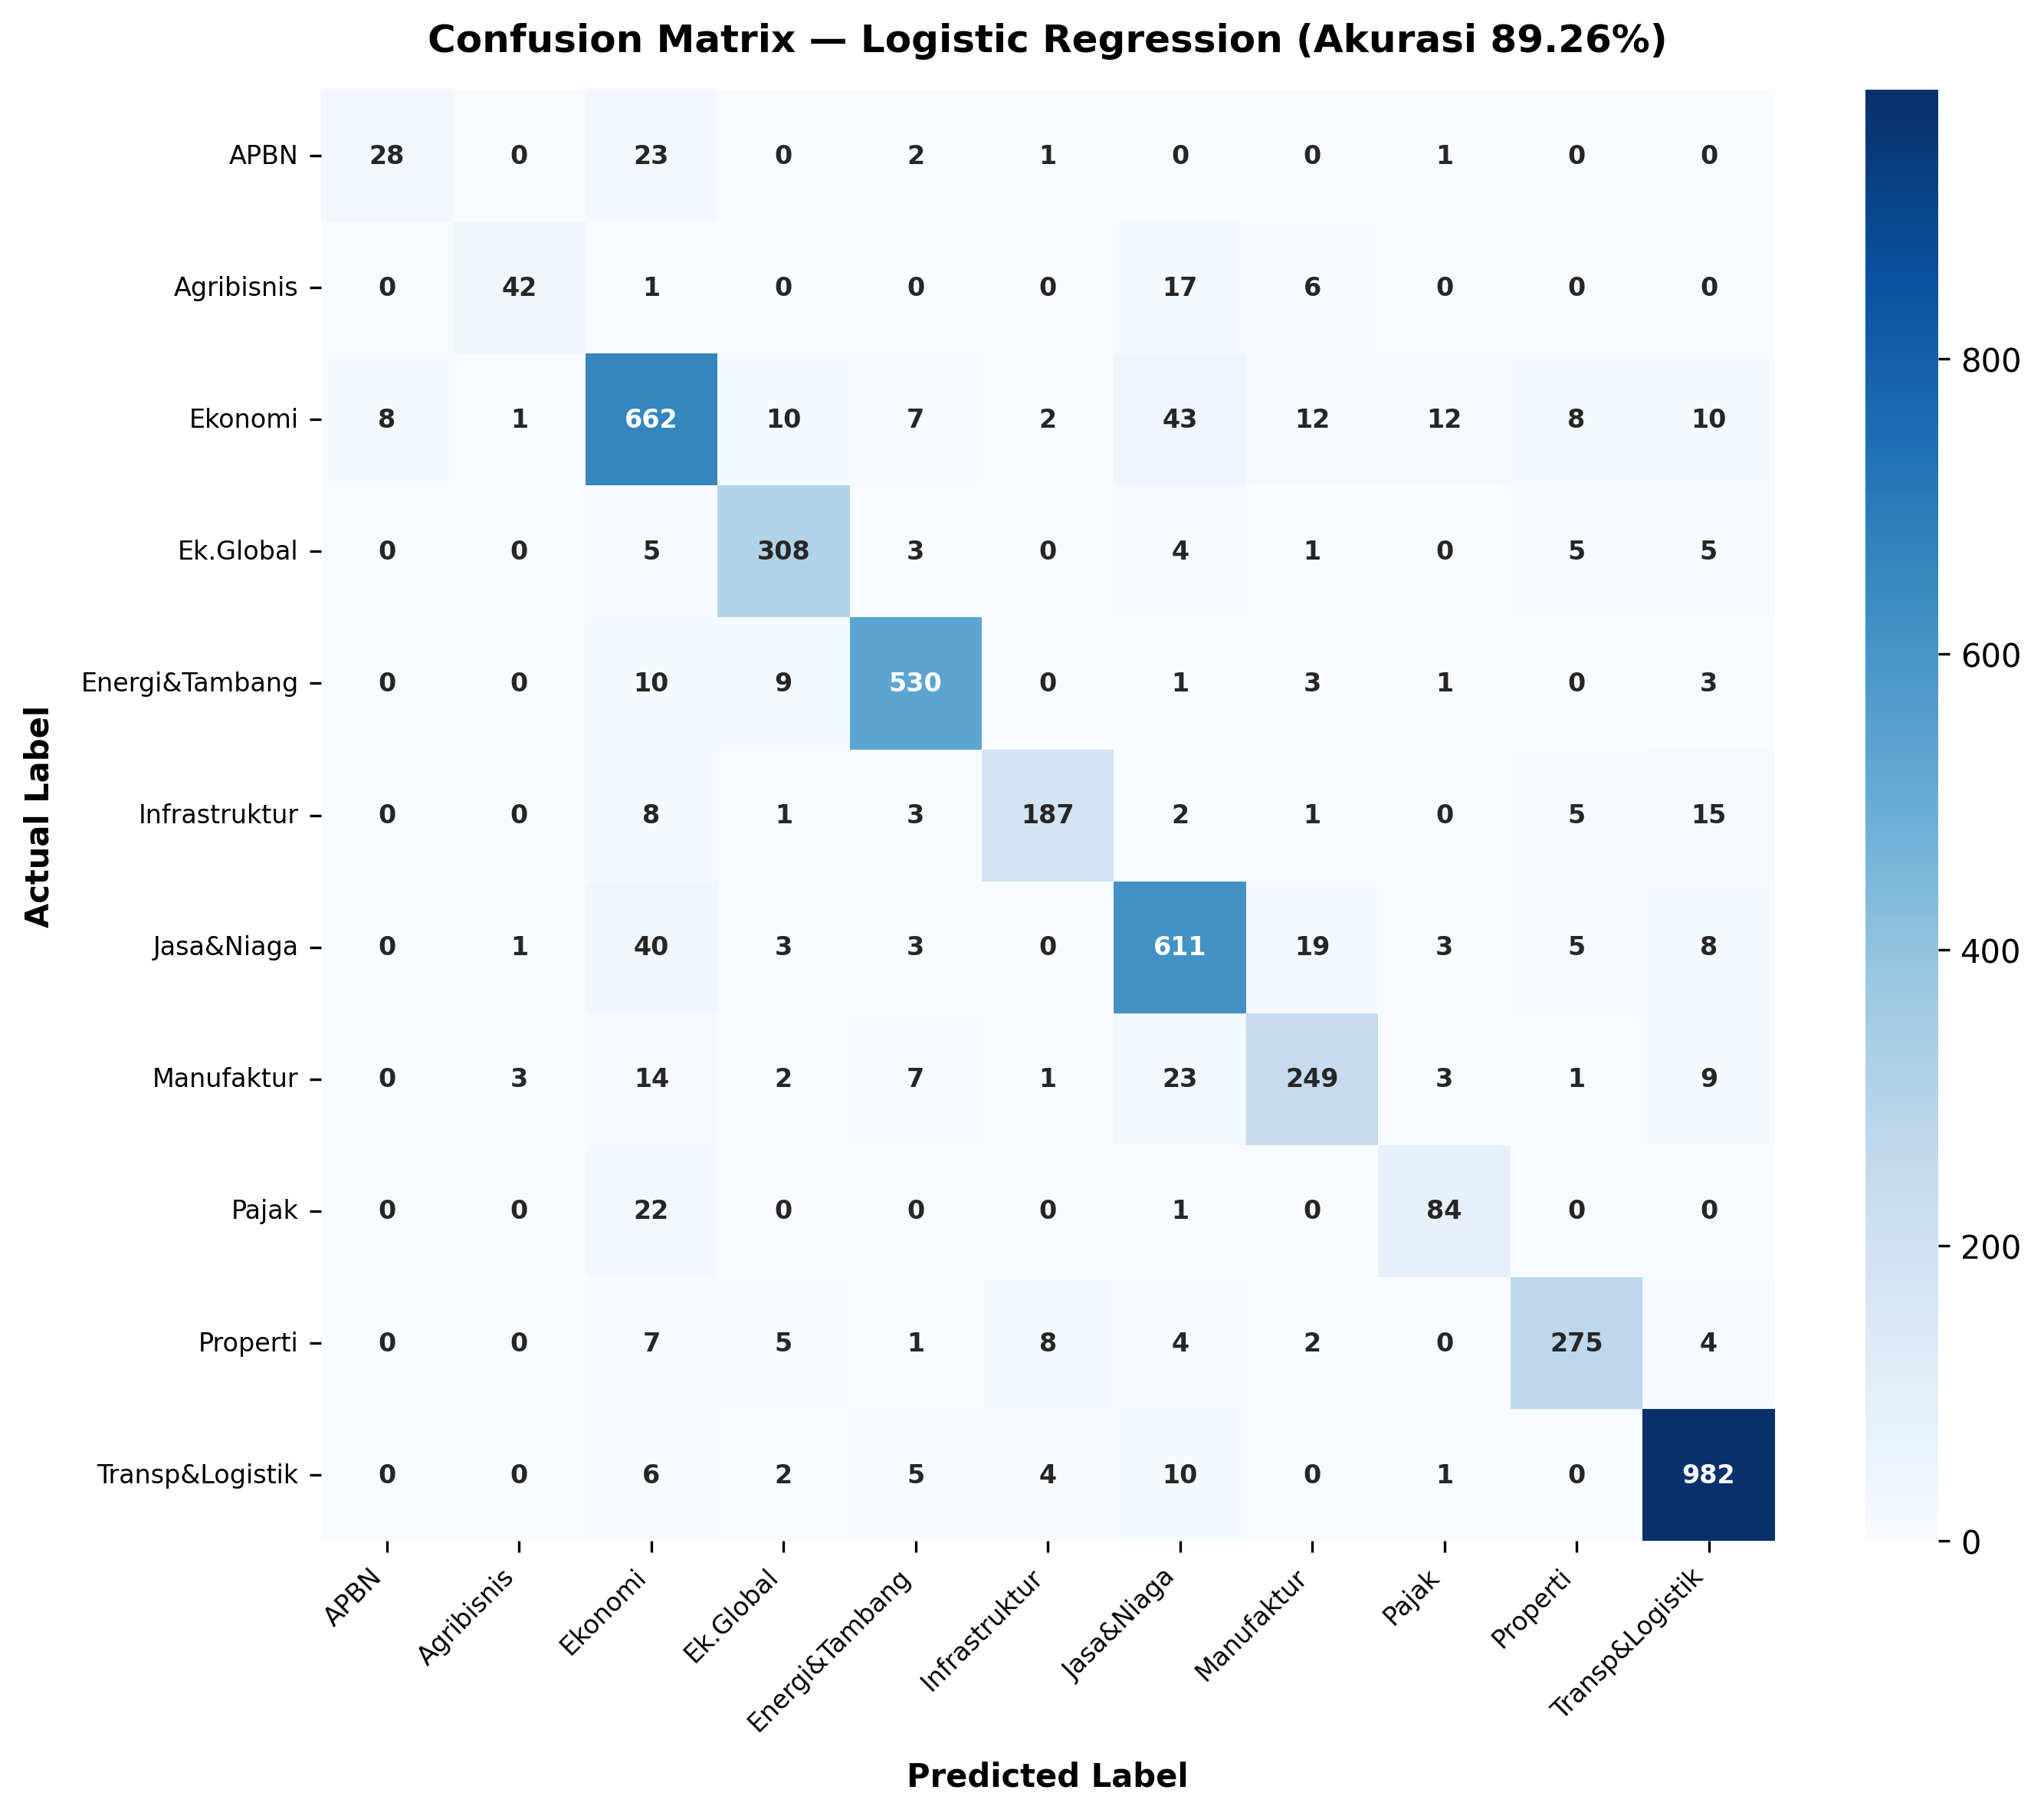

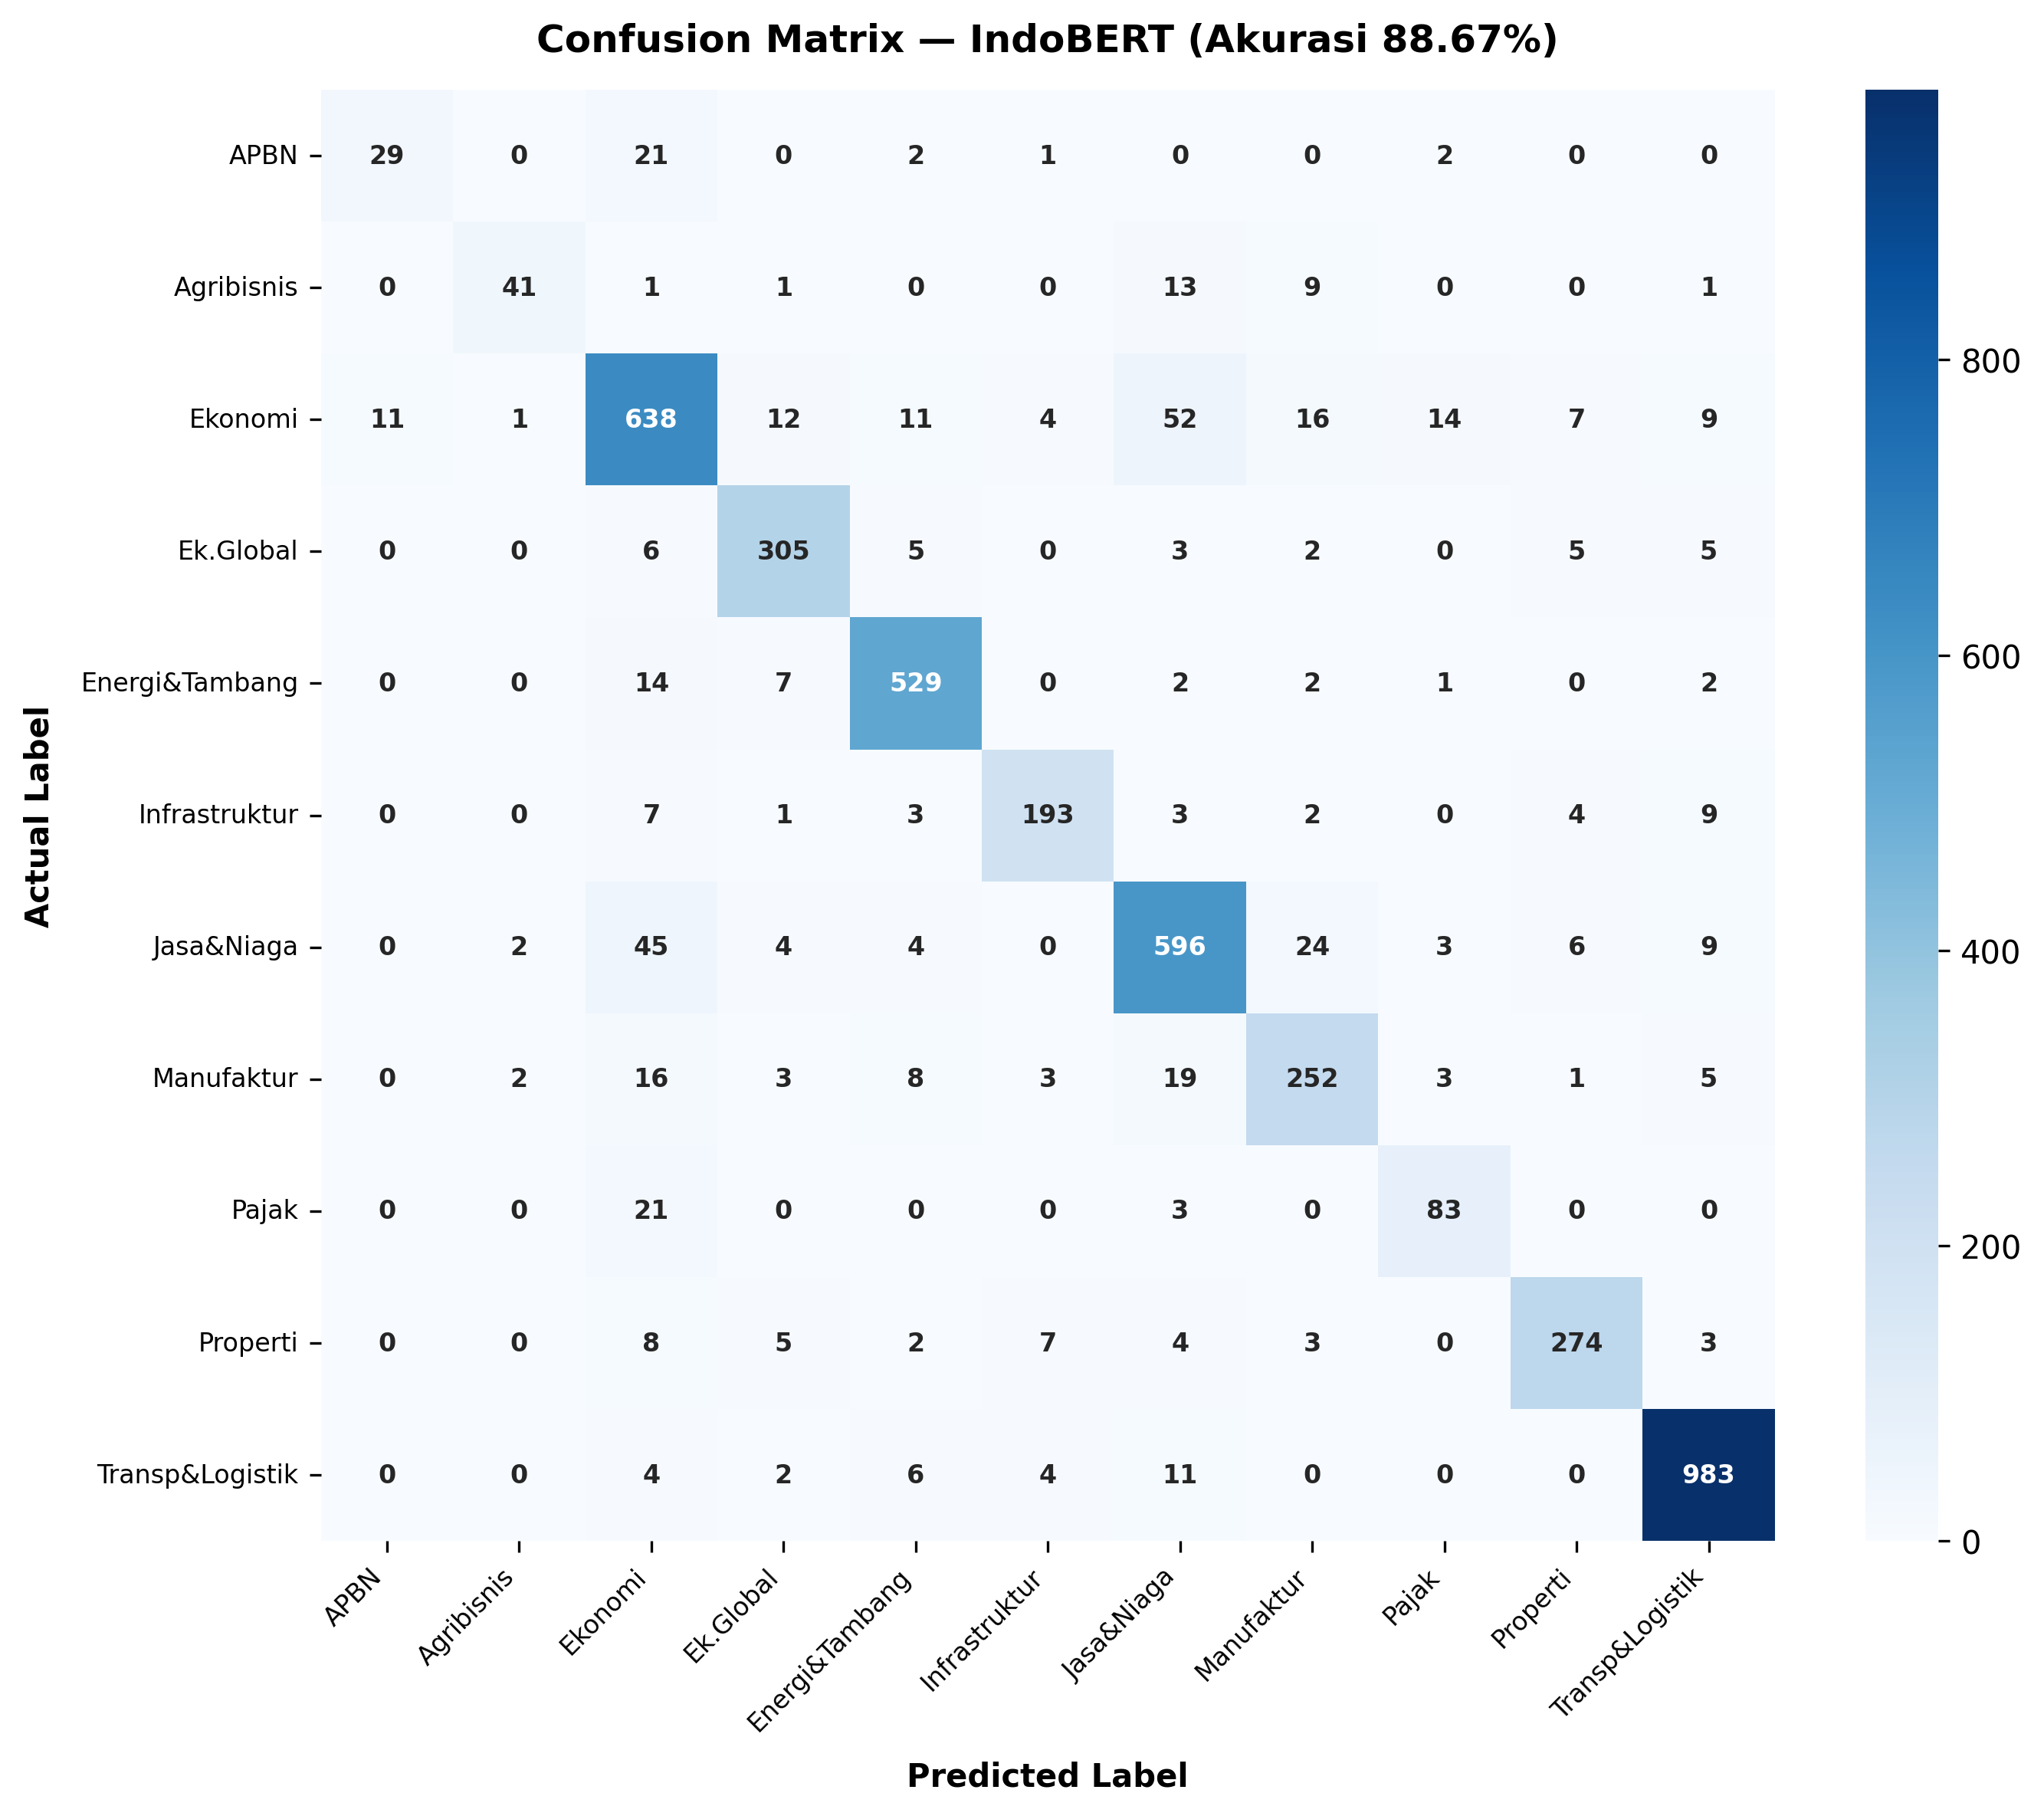

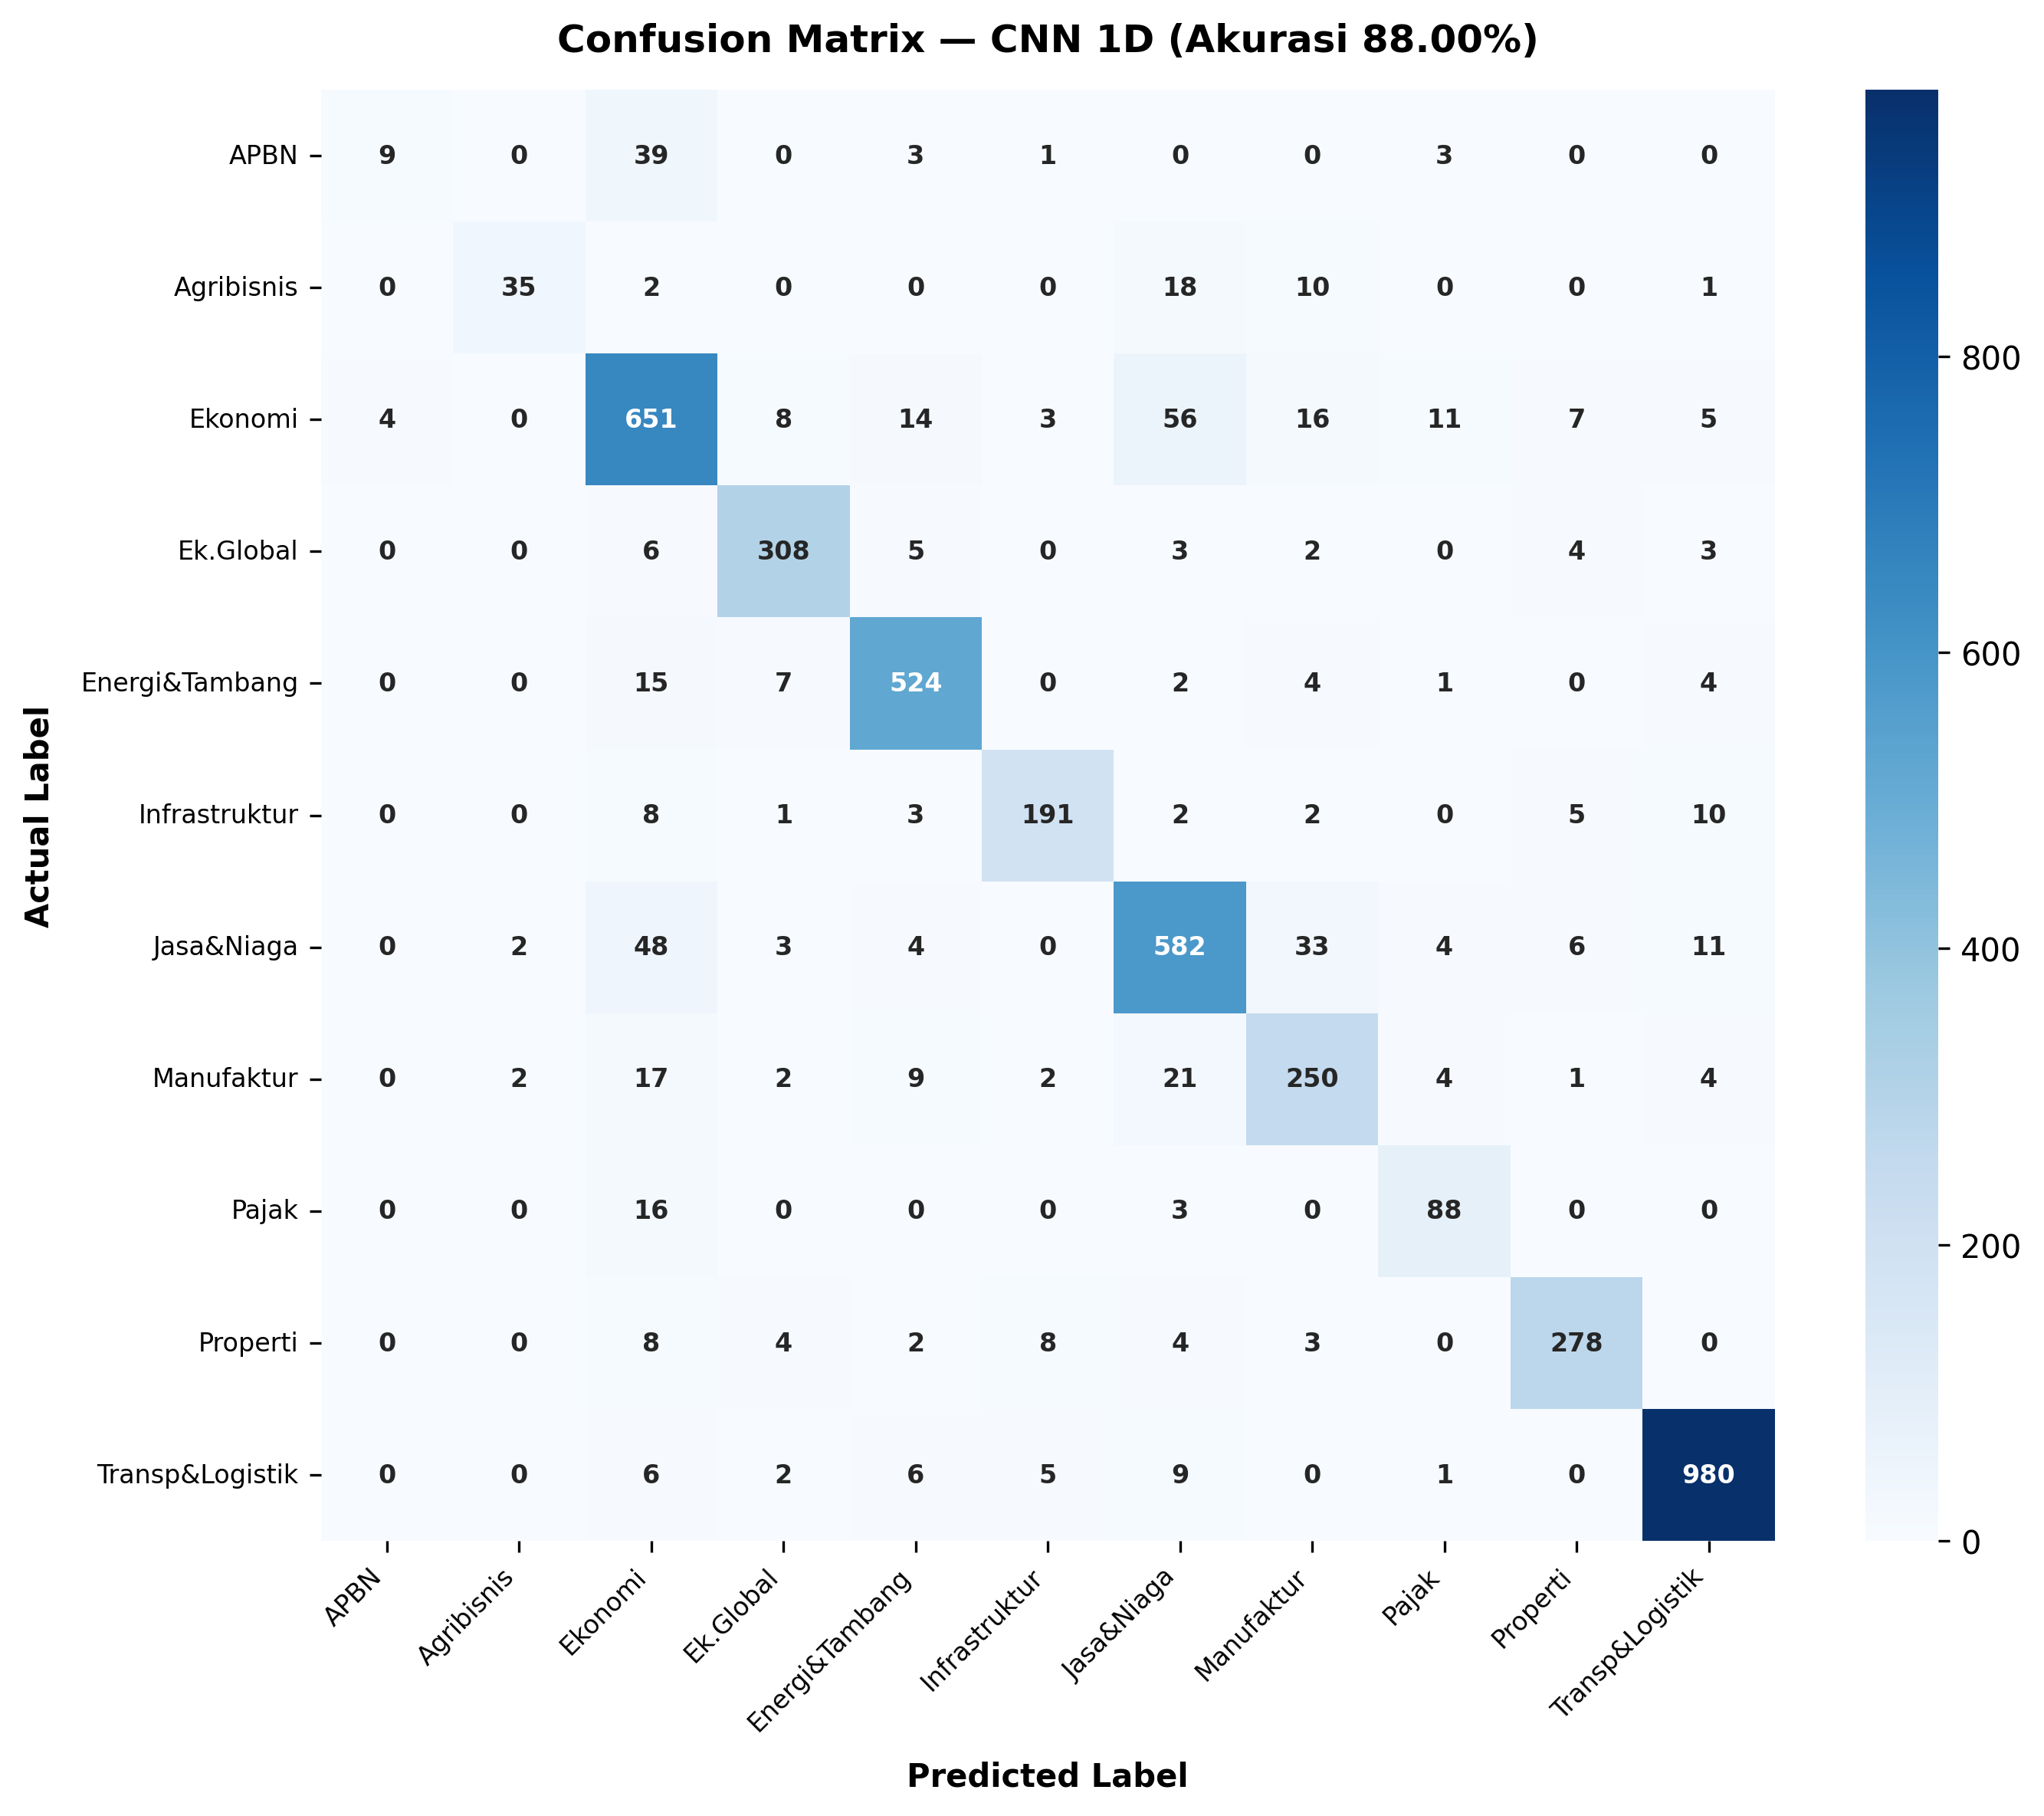

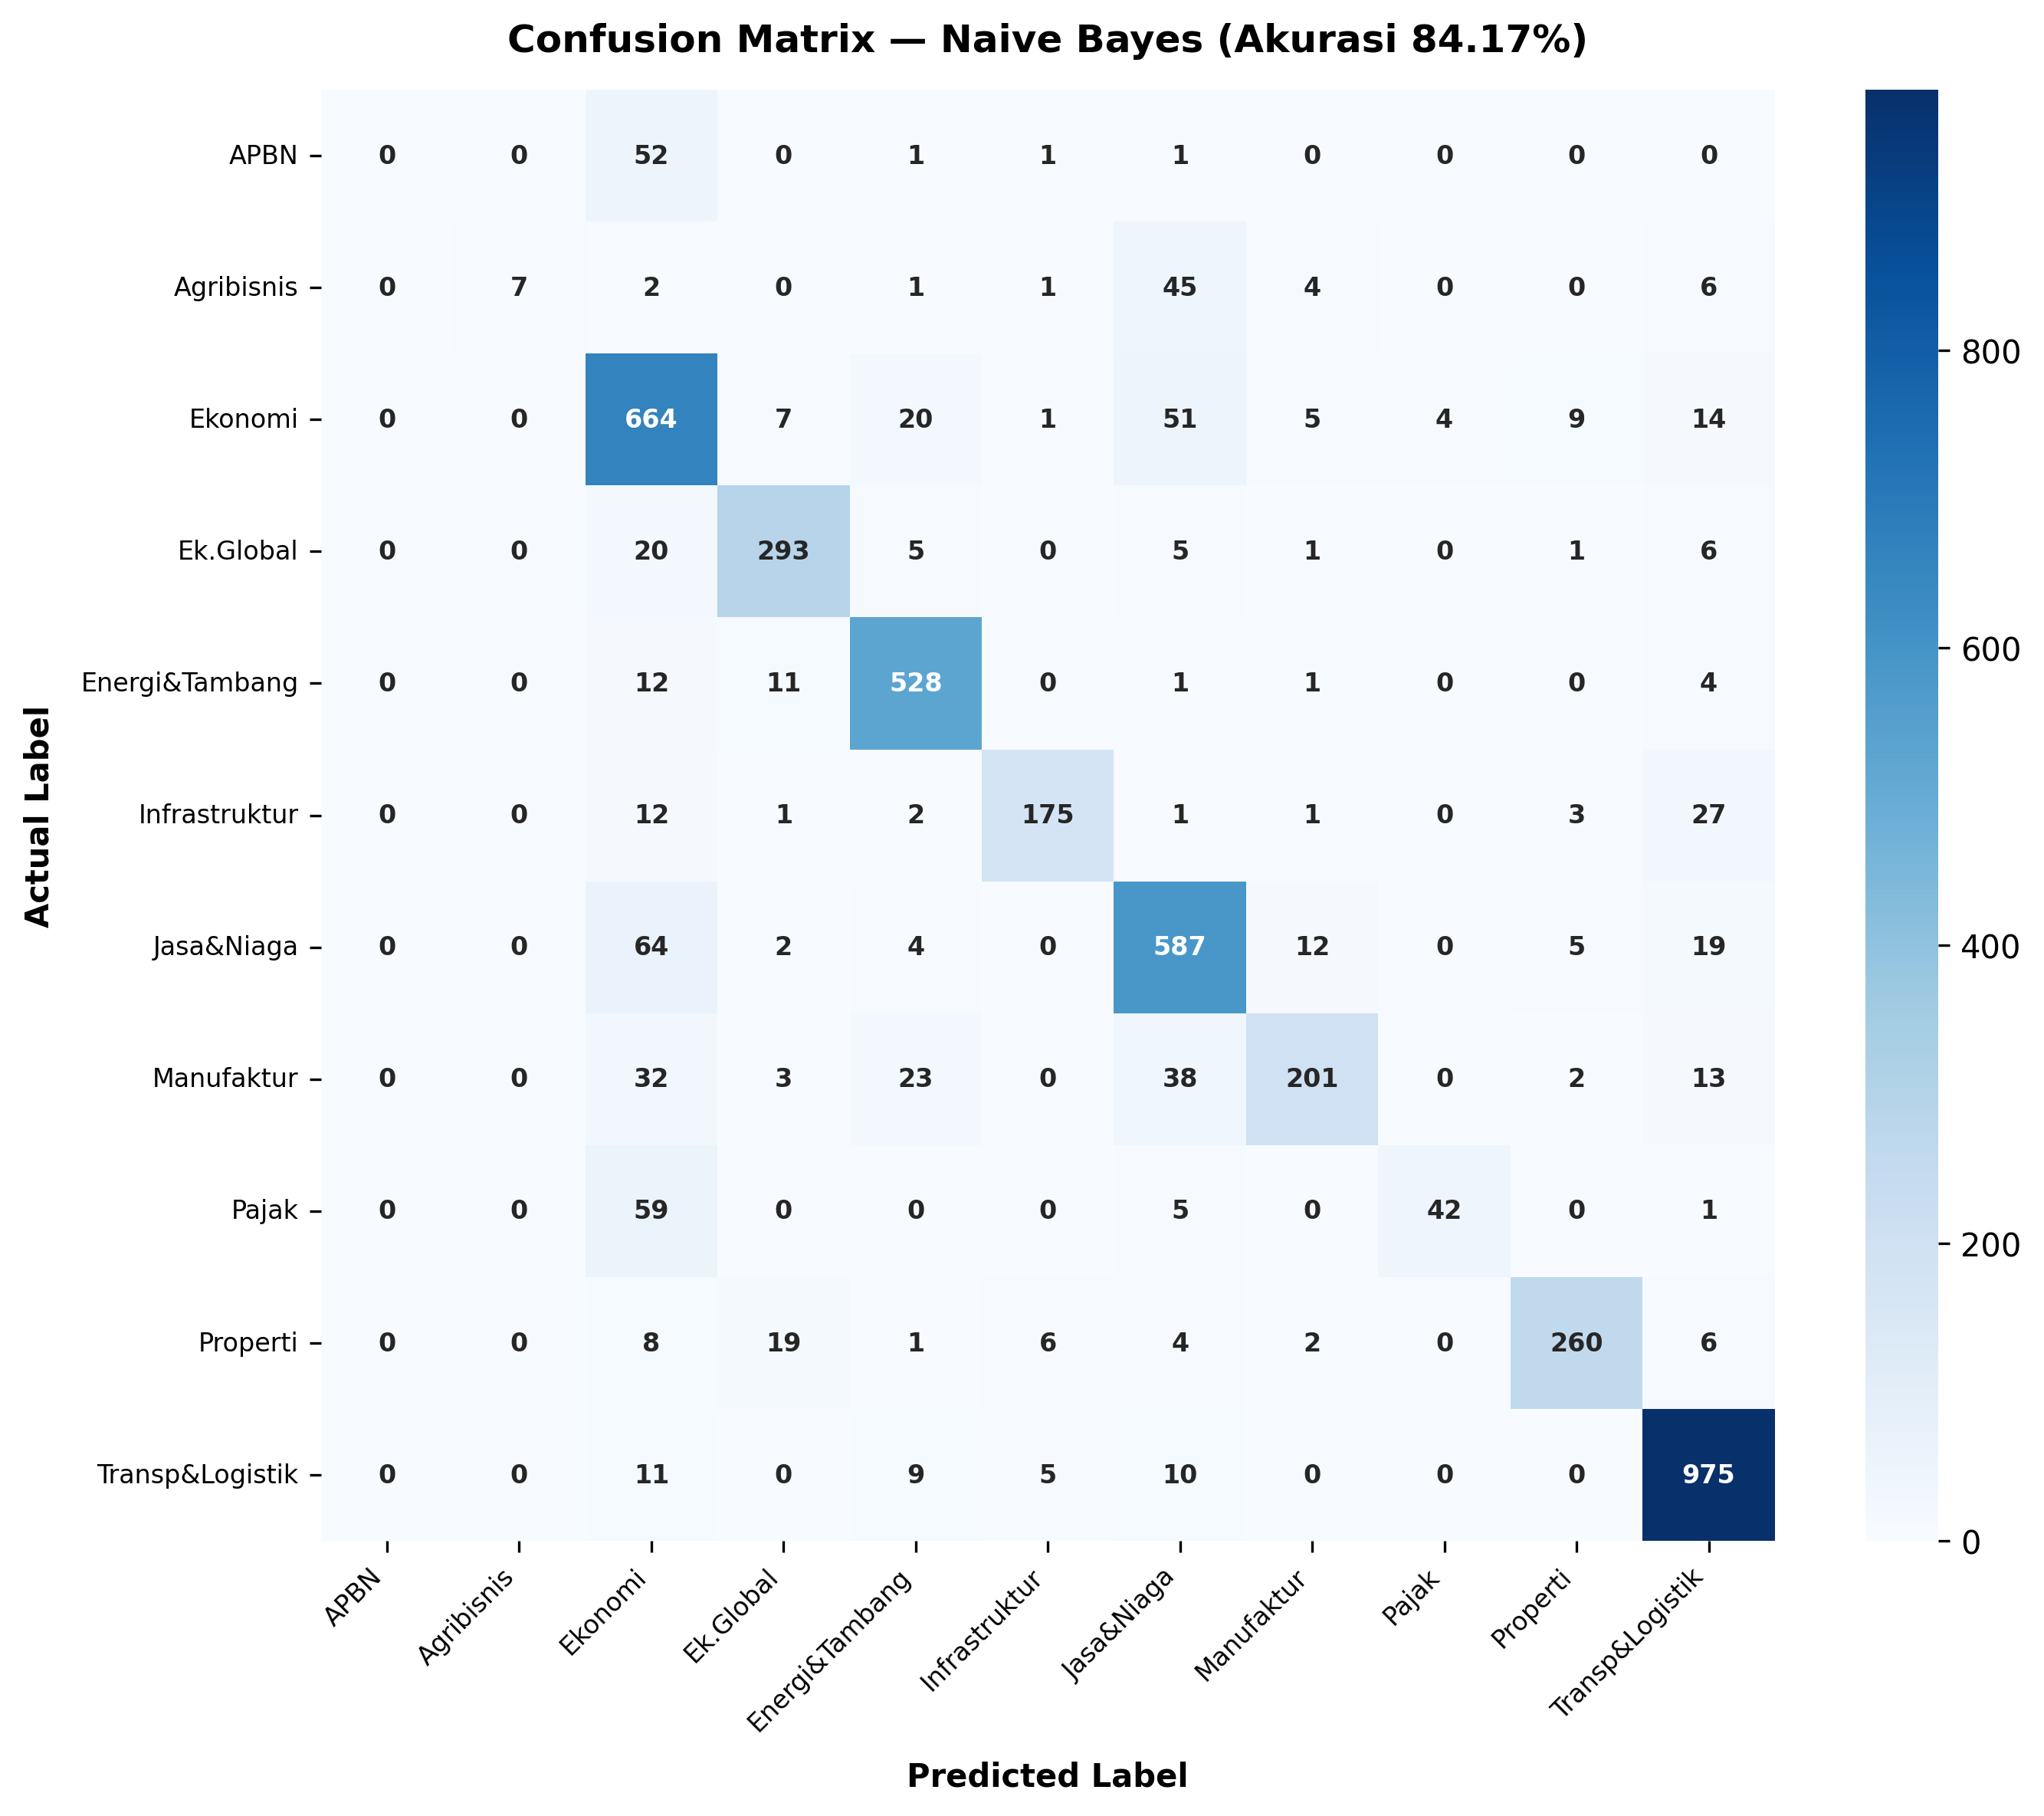

In [5]:
# ==========================================
# GENERASI GAMBAR EVALUASI MODEL JURNAL (Gambar 2 - 10)
# ==========================================
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

classes = ['APBN', 'Agribisnis', 'Ekonomi', 'Ek.Global', 'Energi&Tambang', 'Infrastruktur', 'Jasa&Niaga', 'Manufaktur', 'Pajak', 'Properti', 'Transp&Logistik']

# Data Training vs Validation (Gambar 2-5)
cnn_data = {'epochs': [1,2,3,4,5], 'train_loss': [0.9837,0.3650,0.1799,0.0821,0.0407], 'val_loss': [0.4736,0.3962,0.4358,0.4822,0.5435], 'train_acc': [68.90,89.10,94.77,97.69,98.83], 'val_acc': [85.20,86.83,87.41,86.71,87.37], 'best_epoch': 2}
bilstm_data = {'epochs': [1,2,3], 'train_loss': [1.0394,0.4216,0.2543], 'val_loss': [0.6066,0.5373,0.5786], 'train_acc': [67.16,87.71,92.51], 'val_acc': [82.45,84.75,84.01], 'best_epoch': 2}
cnn_bilstm_data = {'epochs': [1,2,3], 'train_loss': [1.0189,0.4197,0.2597], 'val_loss': [0.5756,0.4948,0.5480], 'train_acc': [67.09,88.02,92.32], 'val_acc': [83.19,84.84,84.50], 'best_epoch': 2}
indobert_data = {'epochs': [1,2,3,4], 'train_loss': [0.5824,0.2915,0.1642,0.0891], 'val_loss': [0.3842,0.3412,0.3685,0.4120], 'val_acc': [87.20,88.95,88.50,88.32], 'best_epoch': 2}

def plot_training_curves(data, model_name, filename):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5), dpi=300)
    epochs = data['epochs']
    best = data['best_epoch']
    
    ax1.plot(epochs, data['train_loss'], 'o-', color='#1f77b4', linewidth=2, label='Training Loss')
    ax1.plot(epochs, data['val_loss'], 's-', color='#ff7f0e', linewidth=2, label='Validation Loss')
    ax1.axvline(x=best, color='red', linestyle='--', linewidth=1.5, label=f'Best Epoch ({best})')
    ax1.set_title(f'Loss Curve — {model_name}', fontsize=12, fontweight='bold')
    ax1.set_xlabel('Epoch', fontweight='bold')
    ax1.set_ylabel('Loss', fontweight='bold')
    ax1.set_xticks(epochs)
    ax1.grid(True, linestyle=':', alpha=0.6)
    ax1.legend()

    if 'train_acc' in data:
        ax2.plot(epochs, data['train_acc'], 'o-', color='#2ca02c', linewidth=2, label='Training Accuracy')
    ax2.plot(epochs, data['val_acc'], 's-', color='#d62728', linewidth=2, label='Validation Accuracy')
    ax2.axvline(x=best, color='red', linestyle='--', linewidth=1.5, label=f'Best Epoch ({best})')
    ax2.set_title(f'Accuracy Curve — {model_name}', fontsize=12, fontweight='bold')
    ax2.set_xlabel('Epoch', fontweight='bold')
    ax2.set_ylabel('Accuracy (%)', fontweight='bold')
    ax2.set_xticks(epochs)
    ax2.grid(True, linestyle=':', alpha=0.6)
    ax2.legend()
    
    plt.tight_layout()
    plt.savefig(f'{output_dir}/figures/{filename}', bbox_inches='tight', dpi=300)
    plt.show()

plot_training_curves(cnn_data, 'CNN 1D', 'Gambar_2_Kurva_Training_vs_Validation_CNN1D.png')
plot_training_curves(bilstm_data, 'BiLSTM', 'Gambar_3_Kurva_Training_vs_Validation_BiLSTM.png')
plot_training_curves(cnn_bilstm_data, 'CNN-BiLSTM', 'Gambar_4_Kurva_Training_vs_Validation_CNN_BiLSTM.png')
plot_training_curves(indobert_data, 'IndoBERT', 'Gambar_5_Kurva_Training_vs_Validation_IndoBERT.png')

# Confusion Matrices (Gambar 6-10)
cms = {
    'Gambar_6_Confusion_Matrix_SVM.png': ('SVM (Akurasi 90.12%)', np.array([[33,0,18,0,2,1,0,0,1,0,0],[0,46,0,1,0,0,10,7,0,1,1],[14,0,652,10,9,3,44,12,12,9,10],[0,0,4,312,4,0,2,1,0,4,4],[0,0,11,6,533,0,1,2,1,0,3],[0,0,4,1,3,197,2,2,0,4,9],[0,3,41,3,3,0,608,20,2,5,8],[0,3,13,2,7,2,15,261,3,1,5],[0,0,20,0,0,0,2,0,85,0,0],[0,0,5,4,1,5,2,4,0,282,3],[0,0,3,2,6,4,8,0,0,0,987]])),
    'Gambar_7_Confusion_Matrix_Logistic_Regression.png': ('Logistic Regression (Akurasi 89.26%)', np.array([[28,0,23,0,2,1,0,0,1,0,0],[0,42,1,0,0,0,17,6,0,0,0],[8,1,662,10,7,2,43,12,12,8,10],[0,0,5,308,3,0,4,1,0,5,5],[0,0,10,9,530,0,1,3,1,0,3],[0,0,8,1,3,187,2,1,0,5,15],[0,1,40,3,3,0,611,19,3,5,8],[0,3,14,2,7,1,23,249,3,1,9],[0,0,22,0,0,0,1,0,84,0,0],[0,0,7,5,1,8,4,2,0,275,4],[0,0,6,2,5,4,10,0,1,0,982]])),
    'Gambar_8_Confusion_Matrix_IndoBERT.png': ('IndoBERT (Akurasi 88.67%)', np.array([[29,0,21,0,2,1,0,0,2,0,0],[0,41,1,1,0,0,13,9,0,0,1],[11,1,638,12,11,4,52,16,14,7,9],[0,0,6,305,5,0,3,2,0,5,5],[0,0,14,7,529,0,2,2,1,0,2],[0,0,7,1,3,193,3,2,0,4,9],[0,2,45,4,4,0,596,24,3,6,9],[0,2,16,3,8,3,19,252,3,1,5],[0,0,21,0,0,0,3,0,83,0,0],[0,0,8,5,2,7,4,3,0,274,3],[0,0,4,2,6,4,11,0,0,0,983]])),
    'Gambar_9_Confusion_Matrix_CNN_1D.png': ('CNN 1D (Akurasi 88.00%)', np.array([[9,0,39,0,3,1,0,0,3,0,0],[0,35,2,0,0,0,18,10,0,0,1],[4,0,651,8,14,3,56,16,11,7,5],[0,0,6,308,5,0,3,2,0,4,3],[0,0,15,7,524,0,2,4,1,0,4],[0,0,8,1,3,191,2,2,0,5,10],[0,2,48,3,4,0,582,33,4,6,11],[0,2,17,2,9,2,21,250,4,1,4],[0,0,16,0,0,0,3,0,88,0,0],[0,0,8,4,2,8,4,3,0,278,0],[0,0,6,2,6,5,9,0,1,0,980]])),
    'Gambar_10_Confusion_Matrix_Naive_Bayes.png': ('Naive Bayes (Akurasi 84.17%)', np.array([[0,0,52,0,1,1,1,0,0,0,0],[0,7,2,0,1,1,45,4,0,0,6],[0,0,664,7,20,1,51,5,4,9,14],[0,0,20,293,5,0,5,1,0,1,6],[0,0,12,11,528,0,1,1,0,0,4],[0,0,12,1,2,175,1,1,0,3,27],[0,0,64,2,4,0,587,12,0,5,19],[0,0,32,3,23,0,38,201,0,2,13],[0,0,59,0,0,0,5,0,42,0,1],[0,0,8,19,1,6,4,2,0,260,6],[0,0,11,0,9,5,10,0,0,0,975]]))
}

for fname, (title, cm) in cms.items():
    fig, ax = plt.subplots(figsize=(9.5, 8), dpi=300)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes, cbar=True, ax=ax, annot_kws={'size': 8, 'weight': 'bold'})
    ax.set_title(f'Confusion Matrix — {title}', fontsize=12, fontweight='bold', pad=12)
    ax.set_xlabel('Predicted Label', fontsize=10, fontweight='bold', labelpad=8)
    ax.set_ylabel('Actual Label', fontsize=10, fontweight='bold', labelpad=8)
    plt.xticks(rotation=45, ha='right', fontsize=8)
    plt.yticks(rotation=0, fontsize=8)
    plt.tight_layout()
    plt.savefig(f'{output_dir}/figures/{fname}', bbox_inches='tight', dpi=300)
    plt.show()
